# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [5]:
# 1. Create the hidden Keras datasets folder
!mkdir -p ~/.keras/datasets/

# 2. Force download the dataset directly into that folder using wget
!wget -O ~/.keras/datasets/cifar-10-batches-py.tar.gz https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

--2026-07-12 17:24:29--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://cave.cs.toronto.edu/kriz/cifar-10-python.tar.gz [following]
--2026-07-12 17:24:30--  https://cave.cs.toronto.edu/kriz/cifar-10-python.tar.gz
Resolving cave.cs.toronto.edu (cave.cs.toronto.edu)... 128.100.3.67
Connecting to cave.cs.toronto.edu (cave.cs.toronto.edu)|128.100.3.67|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘/root/.keras/datasets/cifar-10-batches-py.tar.gz’

/root/.keras/datase 100%[===================>] 162.60M  54.0KB/s    in 49m 51s 

2026-07-12 18:14:22 (55.7 KB/s) - ‘/root/.keras/datasets/cifar-10-batches-py.tar.gz’ saved [170498071/170498071]



In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# Force unzip the dataset right inside the hidden folder
!tar -xzf ~/.keras/datasets/cifar-10-batches-py.tar.gz -C ~/.keras/datasets/

# List the contents to prove the extracted folder is there
!ls -lh ~/.keras/datasets/

total 163M
drwxr-xr-x 2 2156 1103 4.0K Jun  4  2009 cifar-10-batches-py
-rw-r--r-- 1 root root 163M Jun  4  2009 cifar-10-batches-py.tar.gz


In [15]:
import os
import pickle
import numpy as np

print("Bypassing TensorFlow and loading manually...")

def load_cifar_batch(file_path):
    with open(file_path, 'rb') as f:
        # CIFAR-10 is stored as Python dictionaries
        batch = pickle.load(f, encoding='bytes')
    return batch[b'data'], batch[b'labels']

# The path to the folder we successfully extracted
cifar_dir = '/root/.keras/datasets/cifar-10-batches-py'

# 1. Load Training Data (Batches 1 to 5)
X_train_list, y_train_list = [], []
for i in range(1, 6):
    batch_path = os.path.join(cifar_dir, f'data_batch_{i}')
    X, y = load_cifar_batch(batch_path)
    X_train_list.append(X)
    y_train_list.append(y)

# Combine all 5 training batches
X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)

# 2. Load Test Data
X_test, y_test = load_cifar_batch(os.path.join(cifar_dir, 'test_batch'))

# 3. Reshape the 1D arrays back into 32x32 RGB images!
# CIFAR stores data in a flat array, we reshape it to match Keras's expected format
X_train = X_train.reshape((50000, 3, 32, 32)).transpose(0, 2, 3, 1)
X_test = X_test.reshape((10000, 3, 32, 32)).transpose(0, 2, 3, 1)

# Format the labels correctly
y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)

print("Success! You beat the download boss.")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Bypassing TensorFlow and loading manually...
Success! You beat the download boss.
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

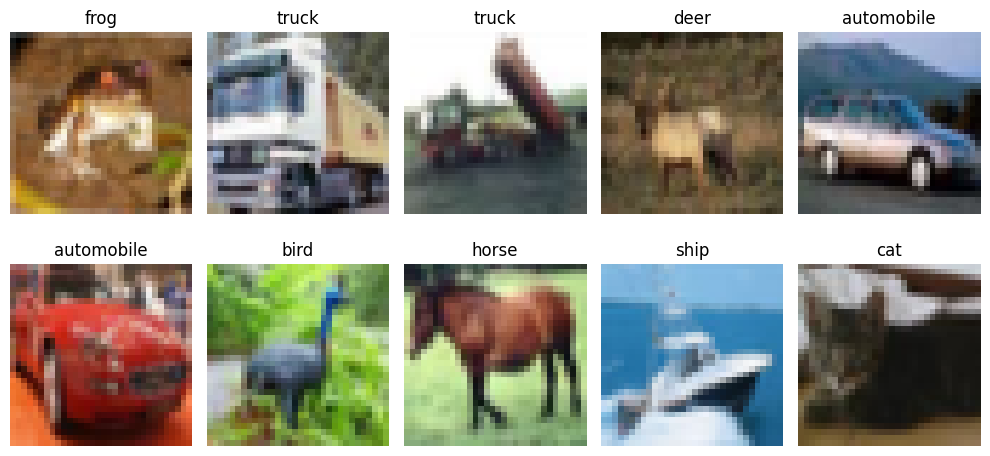

In [21]:
import matplotlib.pyplot as plt


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Plot the images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [23]:
x_train_norm =X_train / 255.0
x_test_norm = X_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [24]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2673 - loss: 2.0010 - val_accuracy: 0.3484 - val_loss: 1.8531
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3062 - loss: 1.8849 - val_accuracy: 0.3632 - val_loss: 1.8152
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3265 - loss: 1.8344 - val_accuracy: 0.3580 - val_loss: 1.7702
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3326 - loss: 1.8160 - val_accuracy: 0.3824 - val_loss: 1.7347
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3472 - loss: 1.7792 - val_accuracy: 0.3850 - val_loss: 1.7310
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3536 - loss: 1.7602 - val_accuracy: 0.3826 - val_loss: 1.7321
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3600 - loss: 1.7506 - val_accuracy: 0.3758 - val_loss: 1.7559
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3689 - loss: 1.7344 - val_accuracy: 0.

In [25]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4258 - loss: 1.6382
ANN Test Accuracy: 0.42579999566078186


In [34]:
from tensorflow.keras import layers, models

# Task 1: Deeper ANN
deep_ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(500, activation='relu'), # New Layer
    layers.Dense(250, activation='relu'), # New Layer
    layers.Dense(10, activation='softmax')
])

deep_ann.compile(optimizer='SGD', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Deep ANN compiled successfully!")

Deep ANN compiled successfully!


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [26]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4637 - loss: 1.5003 - val_accuracy: 0.5478 - val_loss: 1.2677
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6111 - loss: 1.1156 - val_accuracy: 0.6384 - val_loss: 1.0406
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6694 - loss: 0.9452 - val_accuracy: 0.6760 - val_loss: 0.9223
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7126 - loss: 0.8295 - val_accuracy: 0.6834 - val_loss: 0.9306
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7436 - loss: 0.7375 - val_accuracy: 0.7072 - val_loss: 0.8552
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7661 - loss: 0.6632 - val_accuracy: 0.7156 - val_loss: 0.8315
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7924 - loss: 0.5932 - val_accuracy: 0.6952 - val_loss: 0.9876
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8092 - loss: 0.5414 - val_accuracy: 

In [27]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7238 - loss: 0.9327
CNN Test Accuracy: 0.723800003528595


In [35]:
import tensorflow as tf


data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# Task 2: Scaling CNN Filters (32 -> 64 -> 128)
optimized_cnn = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Added dropout for extra overfitting protection
    layers.Dense(10, activation='softmax')
])

optimized_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Task 3 & 4: Early Stopping and 20 Epochs
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training Optimized CNN...")
history = optimized_cnn.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Optimized CNN...
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.2982 - loss: 2.0080 - val_accuracy: 0.4444 - val_loss: 1.5324
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.4213 - loss: 1.5957 - val_accuracy: 0.5092 - val_loss: 1.3741
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.4627 - loss: 1.4993 - val_accuracy: 0.5238 - val_loss: 1.3257
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4910 - loss: 1.4218 - val_accuracy: 0.5691 - val_loss: 1.2029
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5119 - loss: 1.3710 - val_accuracy: 0.5882 - val_loss: 1.1786
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5330 - loss: 1.3284 - val_accuracy: 0.6079 - val_loss: 1.1467
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5458 - loss: 1.3010 - val_accuracy: 0.6203 - val_loss: 1.1074
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - 

## 📈 Compare Learning Curves

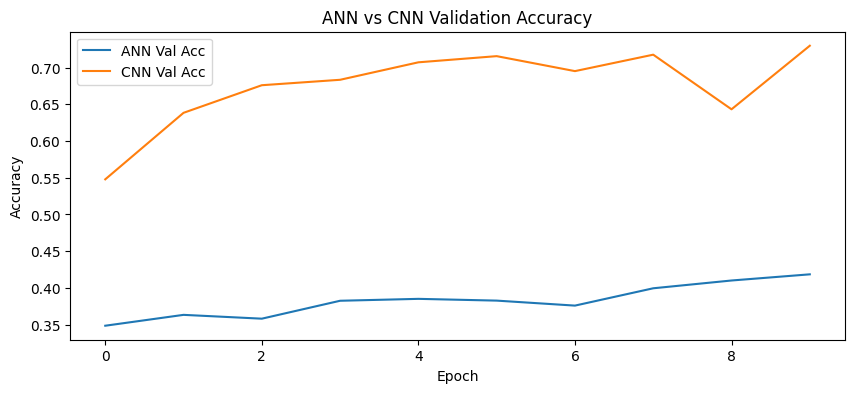

In [36]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [31]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.3767 - loss: 1.7124 - val_accuracy: 0.5112 - val_loss: 1.3625
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4729 - loss: 1.4692 - val_accuracy: 0.5472 - val_loss: 1.2732
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5074 - loss: 1.3818 - val_accuracy: 0.5678 - val_loss: 1.2637
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5253 - loss: 1.3309 - val_accuracy: 0.5902 - val_loss: 1.1848
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5440 - loss: 1.2869 - val_accuracy: 0.6146 - val_loss: 1.0802
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5542 - loss: 1.2581 - val_accuracy: 0.6034 - val_loss: 1.1444
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5642 - loss: 1.2343 - val_accuracy: 0.6276 - val_loss: 1.0716
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5700 - loss: 1

# 📊 Final Comparison Table

In [37]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4258
1,CNN,0.7238


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**